In [122]:
import importlib
import NeuralNetwork

importlib.reload(NeuralNetwork)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [123]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")

CUDA is available. Using GPU: NVIDIA GeForce RTX 3060


In [124]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [125]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [126]:
# Create a DataLoader for batching
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [127]:
# Create model and train
model = NeuralNetwork(hidden_sizes=[512, 256, 128], device=device)

In [128]:
metrics = model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=10)

Epoch 10/10: 100%|██████████| 938/938 [00:19<00:00, 47.91it/s]


In [129]:
print(metrics)

       train_loss  val_loss   val_acc
epoch                                
1        0.164352  0.099777  0.971729
2        0.100020  0.100883  0.970396
3        0.089925  0.087237  0.975667
4        0.085591  0.098768  0.971604
5        0.083794  0.078815  0.977917
6        0.082250  0.104222  0.969667
7        0.081327  0.083781  0.975729
8        0.081440  0.096978  0.974396
9        0.078304  0.083327  0.974812
10       0.077244  0.075321  0.978417


In [130]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

100%|██████████| 157/157 [00:02<00:00, 59.50it/s]


In [131]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 98.12%, Validation: 97.84%, Test: 97.85%


In [132]:
preds = model.predict(test_loader).cpu()

y_true = []
for _, y_batch in test_loader:
    y_true.append(y_batch)
y_true = torch.cat(y_true)

100%|██████████| 157/157 [00:02<00:00, 67.15it/s]


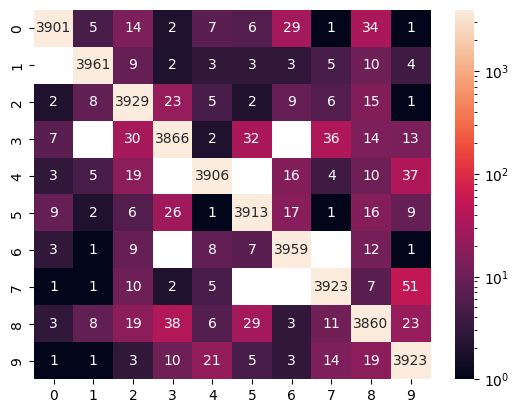

In [133]:
from matplotlib.colors import LogNorm

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, norm=LogNorm(), annot=True, fmt='d')
plt.show()

# Extracting Parameters

In [134]:
layer_data = model.get_layer_data(test_loader)

In [135]:
layer_data['layer_0'].keys()

dict_keys(['weights', 'bias', 'pre_activation', 'post_activation'])

In [136]:
from sklearn.preprocessing import StandardScaler


def get_neuron_features(layer: dict, pre_activation: bool = True):
    n_neurons = len(layer['bias'])

    neurons = []
    for i in range(n_neurons):
        w = layer['weights'][i,:]
        b = layer['bias'][i]
        activation_key = 'pre_activation' if pre_activation else 'post_activation'
        a = layer[activation_key][:,i]

        scaler_w = StandardScaler()
        w_norm = scaler_w.fit_transform(w.reshape(-1,1)).flatten()

        scaler_a = StandardScaler()
        a_norm = scaler_a.fit_transform(a.reshape(-1,1)).flatten()

        neurons.append(np.concatenate([w_norm, [b], a_norm]))
    
    return np.stack(neurons)


In [137]:
neuron_features = get_neuron_features(layer_data['layer_0'])
print(neuron_features.shape)

(512, 40785)


# Clustering

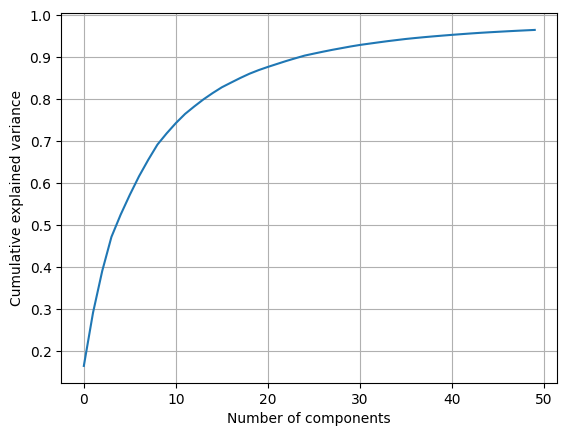

In [138]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
neuron_features_reduced = pca.fit_transform(neuron_features)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid(True)
plt.show()

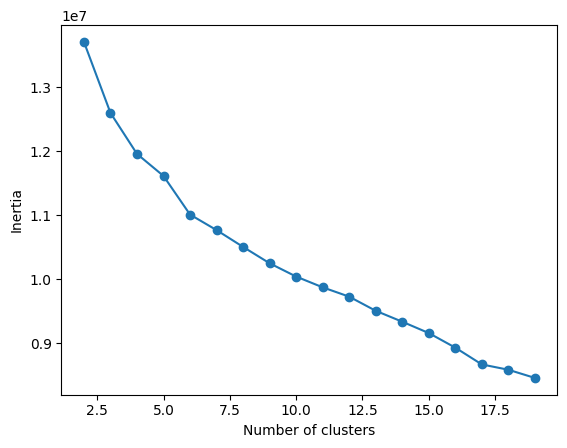

In [139]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 20)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(neuron_features)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

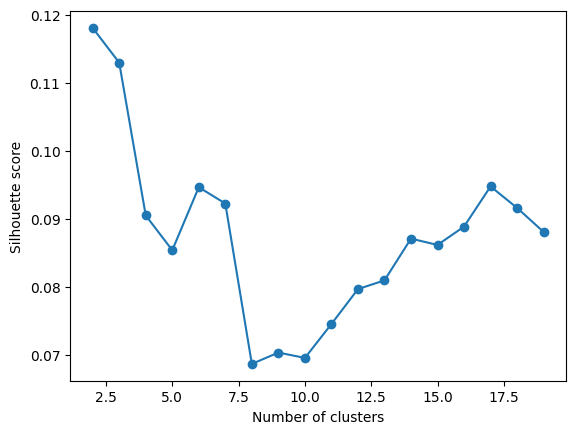

In [140]:
from sklearn.metrics import silhouette_score

scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(neuron_features)
    scores.append(silhouette_score(neuron_features, labels))

plt.plot(K_range, scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

In [141]:
from sklearn.cluster import KMeans

num_clusters = 17
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
clusters = kmeans.fit_predict(neuron_features)

# Visualization

In [154]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_cluster_heatmaps(clusters, activations, weights, cluster_names=None, cmap='bwr'):
    """
    Plot heatmaps for all neuron clusters.
    
    Parameters:
    - clusters: array of cluster assignments, shape [num_neurons]
    - activations: array of post-ReLU activations, shape [num_samples, num_neurons]
    - weights: array of neuron weights, shape [num_neurons, input_dim] (e.g., 784)
    - cluster_names: optional list of cluster labels
    - cmap: colormap (default 'bwr' for positive/negative)
    """
    num_clusters = len(np.unique(clusters))
    cols = 5  # number of heatmaps per row
    rows = int(np.ceil(num_clusters / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = axes.flatten()
    
    for cluster_id in range(num_clusters):
        # Neurons in this cluster
        cluster_neurons = np.where(clusters == cluster_id)[0]
        cluster_activations = activations[:, cluster_neurons]
        cluster_weights = weights[cluster_neurons, :]
        
        # Average activation per neuron
        neuron_avg_activation = cluster_activations.mean(axis=0)
        
        # Weighted weights
        weighted_weights = (cluster_weights.T * neuron_avg_activation).T
        mean_weighted_image = weighted_weights.mean(axis=0).reshape(28, 28)
        

        # Plot
        ax = axes[cluster_id]
        im = ax.imshow(mean_weighted_image, cmap=cmap)
        title = f"Cluster {cluster_id}" if cluster_names is None else cluster_names[cluster_id]
        ax.set_title(title)
        ax.axis('off')
    
    # Remove empty subplots
    for i in range(num_clusters, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.colorbar(im, ax=axes.tolist(), shrink=0.6)
    plt.show()

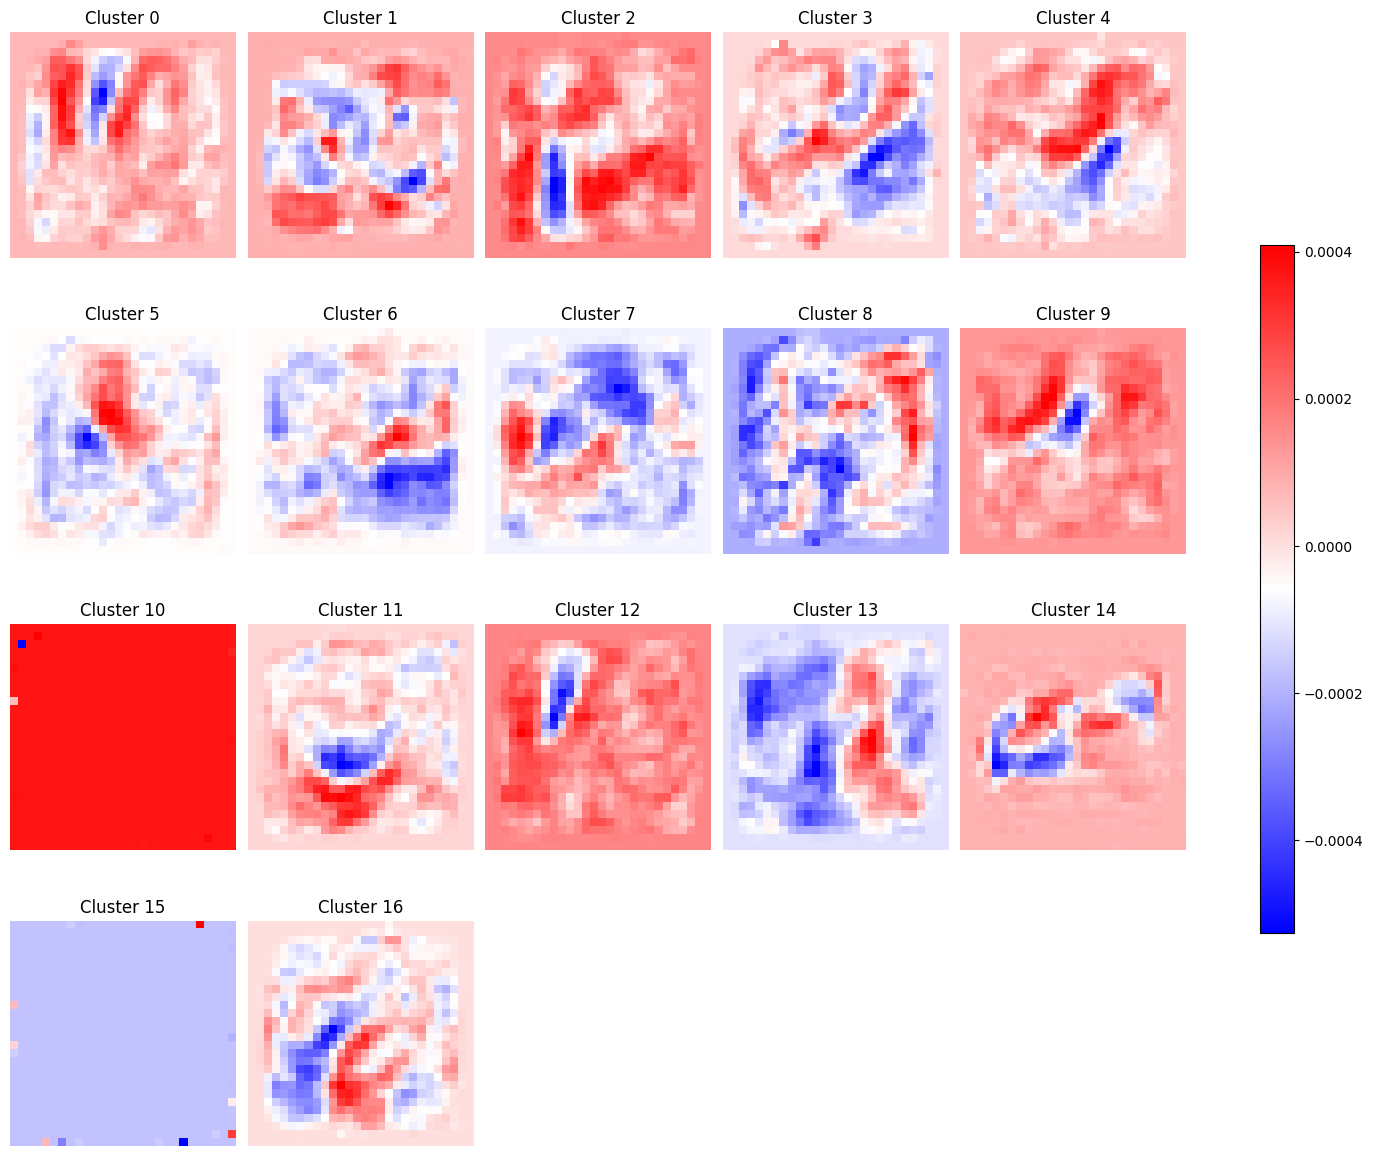

In [155]:
activations = layer_data['layer_0']['post_activation']
weights = layer_data['layer_0']['weights']

plot_all_cluster_heatmaps(clusters, activations, weights)